<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
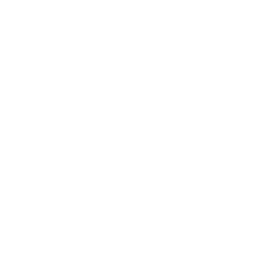
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Bank Monthly Balance Pivot for Trend Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Retail Banking / Portfolio Analytics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

A retail bank stores end-of-month account balances in **long format** — one row per account per month. That layout is convenient for ingestion but awkward for per-account, full-year comparisons. This notebook uses **PROC TRANSPOSE** to pivot the long table into **wide format** — one row per account with twelve named monthly columns (`bal_2025_01` … `bal_2025_12`) — then computes each account's January-to-December growth and summarizes that growth by product segment.

The reshape is the analytical enabler: year-over-year growth per account (`(bal_2025_12 - bal_2025_01) / bal_2025_01`) is a single-row calculation in wide format but a self-join in long format. Running the pivot over 20,004 monthly records produced 1,667 one-row-per-account records, and the segment growth summary that follows is computed entirely from that wide table.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.MONTHLY_BALANCES | Synthetic long-format balances: 1,667 accounts × 12 months, 4 product types, 25 branches | 20,004 |
| Derived: WORK.BALANCE_WIDE | Pivoted one-row-per-account, 12 `bal_YYYY_MM` columns | 1,667 |
| Derived: WORK.BALANCE_GROWTH | Adds `annual_growth_pct` (Jan vs Dec) per account | 1,667 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic monthly account balance records
   ~1,667 accounts x 12 months = ~20,000 rows
   -------------------------------------------------------- */
data work.monthly_balances;
    call streaminit(42);
    array prod_list[4] $15 _temporary_ ('CHECKING' 'SAVINGS' 'MONEY_MARKET' 'CD');
    do acct_seq = 1 to 1667;
        account_id = cat('ACCT-', put(acct_seq, z6.));
        prod_idx = int(rand('uniform') * 4) + 1;
        product_type = prod_list[prod_idx];
        branch_code = cat('BR-', put(int(rand('uniform') * 25) + 1, z3.));
        base_balance = round(rand('exponential') * 18000 + 500, 0.01);
        do month_num = 1 to 12;
            balance_month = cat('2025_', put(month_num, z2.));
            /* Simulate gradual growth with monthly noise */
            growth_factor = 1 + (month_num - 1) * 0.005;
            monthly_noise = rand('normal', 0, base_balance * 0.08);
            end_balance = round(base_balance * growth_factor + monthly_noise, 0.01);
            if end_balance < 0 then end_balance = 25.00;
            avg_daily_balance = round(end_balance * (0.92 + rand('uniform') * 0.12), 0.01);
            output;
        end;
    end;
    drop acct_seq prod_idx base_balance growth_factor monthly_noise;
run;

NOTE: DATA work.monthly_balances


NOTE: Wrote work.monthly_balances (20004 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.26 seconds
  cpu   0.26 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline: average balance by product type and month
   -------------------------------------------------------- */
proc means data=work.monthly_balances mean ;
    class product_type balance_month;
    var end_balance avg_daily_balance;
    title 'Monthly Average Balance by Product Type (Long Format)';
run;

                                 Monthly Average Balance by Product Type (Long Format)                                  

                                                  The MEANS Procedure

                                            Analysis Variable : end_balance

                                                 N
        product_type  balance_month            Obs           Mean
        ---------------------------------------------------------
        CD            2025_01                  434  17873.0573041
        CD            2025_02                  434  18107.5299539
        CD            2025_03                  434  18263.4196313
        CD            2025_04                  434  18499.8130415
        CD            2025_05                  434  18509.5059908
        CD            2025_06                  434  18778.4445161
        CD            2025_07                  434  18690.8264516
        CD            2025_08                  434  18699.8477650
        CD         

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                 Monthly Average Balance by Product Type (Long Format)                                  



NOTE: PROC SGPLOT data=work.monthly_balances

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


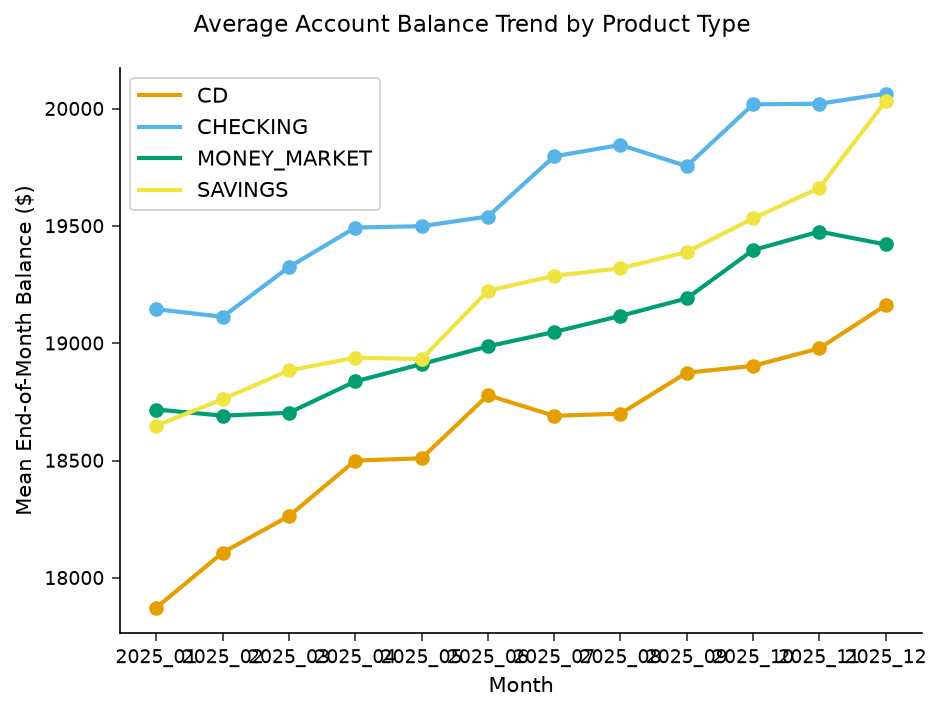

In [3]:
/* --------------------------------------------------------
   Average balance trend by product type
   -------------------------------------------------------- */
proc sgplot data=work.monthly_balances;
    vline balance_month / response=end_balance group=product_type
        stat=mean markers;
    xaxis label='Month' fitpolicy=rotate;
    yaxis label='Mean End-of-Month Balance ($)';
    title 'Average Account Balance Trend by Product Type';
run;

---

In [4]:
/* --------------------------------------------------------
   Sort by the TRANSPOSE BY key so each account forms one
   contiguous BY group (branch_code is constant per account)
   -------------------------------------------------------- */
proc sort data=work.monthly_balances
          out=work.balances_sorted;
    by product_type account_id branch_code;
run;

NOTE: PROC SORT data=work.monthly_balances

NOTE: Read 20004 rows from work.monthly_balances.
NOTE: Wrote work.balances_sorted (20004 rows, 7 columns).
NOTE: PROC SORT statement used.


In [5]:
/* --------------------------------------------------------
   Pivot long monthly balances to wide format
   ID statement uses balance_month to create column names
   PREFIX= adds BAL_ to each month column
   BY product_type account_id branch_code: one output row
   per account; branch_code is constant within an account,
   so it rides along in the BY key (not transposed)
   -------------------------------------------------------- */
proc transpose data=work.balances_sorted
               out=work.balance_wide(drop=_name_)
               prefix=bal_;
    by product_type account_id branch_code;
    id balance_month;
    var end_balance;
run;

NOTE: PROC TRANSPOSE data=work.balances_sorted

NOTE: Created 1667 rows.
NOTE: Output written to ./work/fdc08571-e714-4b83-a32d-da1ed88a82f0/balance_wide.avro.


In [6]:
/* --------------------------------------------------------
   Calculate year-over-year growth per account
   (January vs December) by product segment
   -------------------------------------------------------- */
data work.balance_growth;
    set work.balance_wide;
    if bal_2025_01 > 0 then
        annual_growth_pct = round(((bal_2025_12 - bal_2025_01) / bal_2025_01) * 100, 0.01);
    else annual_growth_pct = .;
run;

proc means data=work.balance_growth n mean std;
    class product_type;
    var annual_growth_pct bal_2025_01 bal_2025_12;
    title 'Annual Balance Growth by Product Segment';
run;

                                        Annual Balance Growth by Product Segment                                        

                                                  The MEANS Procedure

                                         Analysis Variable : annual_growth_pct

        product_type          N Obs           Mean        Std Dev
        ---------------------------------------------------------
        CD                      434      6.7857373     10.9361744
        CHECKING                414      4.9673188     11.8471989
        MONEY_MARKET            414      5.1109903     11.5892395
        SAVINGS                 405      7.2979506     12.3137344
        ---------------------------------------------------------

                                            Analysis Variable : bal_2025_01

        product_type          N Obs           Mean        Std Dev
        ---------------------------------------------------------
        CD                      434  17873.0573041  164

NOTE: DATA work.balance_growth


NOTE: Read 1667 rows from work.balance_wide.
NOTE: Wrote work.balance_growth (1667 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Interpretation

The pivot reshaped **20,004** long-format balance records into **1,667** wide-format rows, each carrying twelve monthly columns prefixed with `bal_`. BY-group processing on `product_type account_id branch_code` kept the product segmentation intact and carried `branch_code` through to the wide table without transposing it.

Annual growth (January → December) summarized by product segment shows that **Savings accounts grew the most** on average, at **7.30%**, narrowly ahead of **CD at 6.79%**; **Money Market (5.11%)** and **Checking (4.97%)** trailed. The growth figures are also the most dispersed where mean growth is highest — Savings carries the largest standard deviation (**12.31 points**) and CD the smallest (**10.94 points**) — so the segment ranking by average growth is not the same as a ranking by reliability of that growth.

Mean end-of-month balances climbed across all four segments over the year (January means near \$17.9k–\$19.1k, December means \$19.2k–\$20.1k), consistent with the trend plot above. Checking carried the highest balances throughout and Savings closed the year essentially tied with Checking, reflecting its stronger growth rate. The wide table and the `annual_balance_growth.csv` export are the artifacts a downstream dashboard or segment-profitability model would consume.

---

In [7]:
/* --------------------------------------------------------
   Export wide-format balance matrix for dashboard
   -------------------------------------------------------- */
proc export data=work.balance_wide
    outfile='account_balance_matrix.csv'
    dbms=csv replace;
run;

proc export data=work.balance_growth
    outfile='annual_balance_growth.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.balance_wide outfile=account_balance_matrix.csv

NOTE: Exported 1667 rows to account_balance_matrix.csv.
NOTE: PROC EXPORT data=work.balance_growth outfile=annual_balance_growth.csv

NOTE: Exported 1667 rows to annual_balance_growth.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>